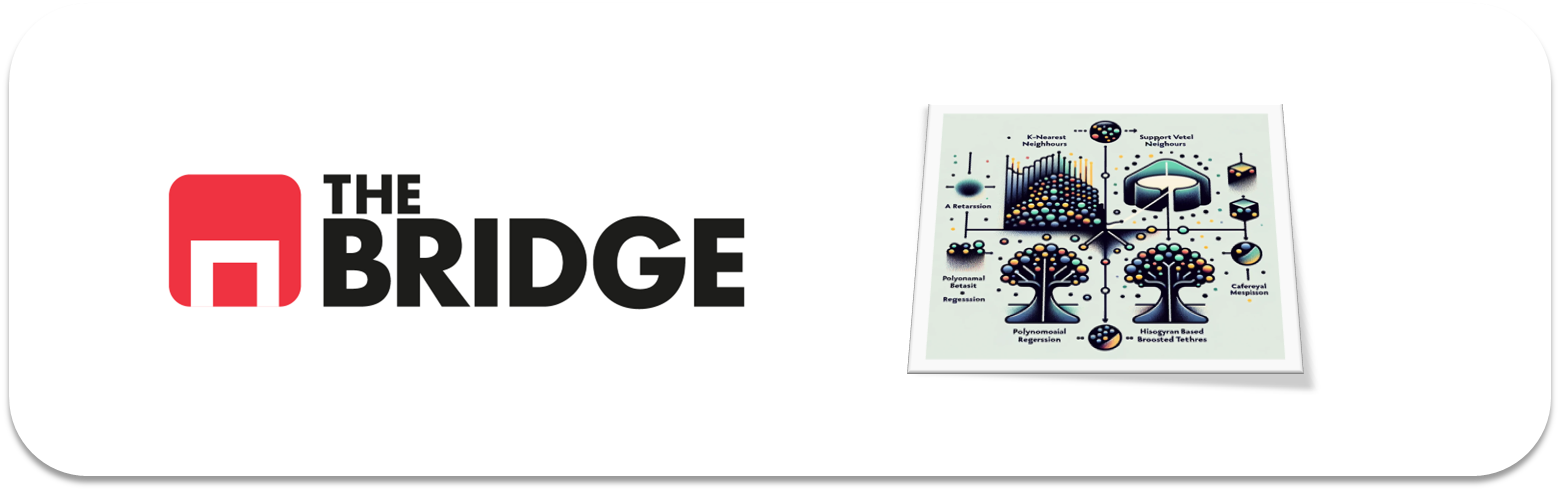

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [82]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, balanced_accuracy_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [83]:
df = pd.read_csv("./data/credit_npo.csv")
target = "SeriousDlqin2yrs"

print(f"Shape: {df.shape}")
df.head()

Shape: (12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [84]:
print("Información del dataset:")
df.info()
print("\nNulos por columna:")
print(df.isnull().sum())

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes

In [85]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


El dataset contiene **12.537 registros** y **11 columnas** (10 features + 1 target). Descripción de cada variable:

| Variable | Tipo | Descripción |
|---|---|---|
| `SeriousDlqin2yrs` | **Target** (binaria) | 1 = dificultades financieras graves en los próximos 2 años; 0 = no |
| `RevolvingUtilizationOfUnsecuredLines` | Numérica continua | Ratio de uso de crédito revolvente sin garantía (tarjetas de crédito, líneas personales) frente al límite total |
| `age` | Numérica discreta | Edad del prestatario en años |
| `NumberOfTime30-59DaysPastDueNotWorse` | Numérica discreta | Nº de veces con 30-59 días de retraso en el pago en los últimos 2 años |
| `DebtRatio` | Numérica continua | Ratio deuda mensual (pagos, pensiones, etc.) / ingreso mensual bruto |
| `MonthlyIncome` | Numérica continua | Ingreso mensual bruto en $ (**721 nulos**) |
| `NumberOfOpenCreditLinesAndLoans` | Numérica discreta | Nº de préstamos y líneas de crédito abiertas |
| `NumberOfTimes90DaysLate` | Numérica discreta | Nº de veces con 90 o más días de retraso en el pago |
| `NumberRealEstateLoansOrLines` | Numérica discreta | Nº de hipotecas y préstamos inmobiliarios |
| `NumberOfTime60-89DaysPastDueNotWorse` | Numérica discreta | Nº de veces con 60-89 días de retraso en el pago en los últimos 2 años |
| `NumberOfDependents` | Numérica discreta | Nº de dependientes en el hogar (cónyuge, hijos...) (**177 nulos**) |

**Clasificación de variables:**
- **Numéricas continuas**: `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `MonthlyIncome`
- **Numéricas discretas**: `age`, variables de retrasos en pagos, `NumberOfOpenCreditLinesAndLoans`, `NumberRealEstateLoansOrLines`, `NumberOfDependents`
- **Categóricas**: ninguna — todas las features son numéricas

Hay nulos en `MonthlyIncome` (721) y `NumberOfDependents` (177) que habrá que imputar antes del modelado.

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Estamos ante un problema de **clasificación binaria supervisada**: el objetivo es predecir si una persona experimentará dificultades financieras graves en los próximos dos años.

La **variable target** es `SeriousDlqin2yrs`:
- **`1`** (positivo): el cliente entrará en dificultades financieras serias en los próximos 2 años.
- **`0`** (negativo): el cliente no tendrá dificultades financieras graves.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

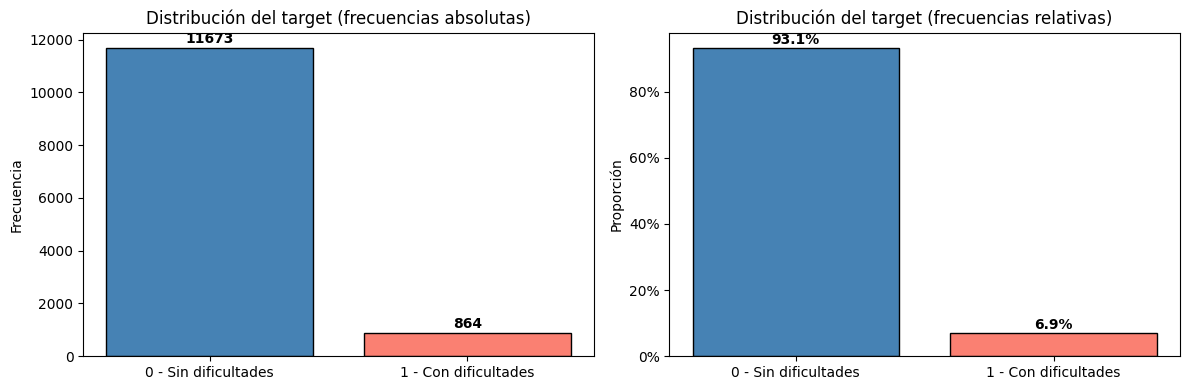

Clase 0 (sin dificultades): 11,673 muestras (93.1%)
Clase 1 (con dificultades): 864 muestras (6.9%)


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[target].value_counts().sort_index()
props  = df[target].value_counts(normalize=True).sort_index()
etiquetas = ["0 - Sin dificultades", "1 - Con dificultades"]
colores = ["steelblue", "salmon"]

bars0 = axes[0].bar(etiquetas, counts.values, color=colores, edgecolor="black")
axes[0].set_title("Distribución del target (frecuencias absolutas)")
axes[0].set_ylabel("Frecuencia")
for bar, val in zip(bars0, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80, str(val),
                 ha="center", va="bottom", fontweight="bold")

bars1 = axes[1].bar(etiquetas, props.values, color=colores, edgecolor="black")
axes[1].set_title("Distribución del target (frecuencias relativas)")
axes[1].set_ylabel("Proporción")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for bar, val in zip(bars1, props.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005, f"{val:.1%}",
                 ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Clase 0 (sin dificultades): {counts[0]:,} muestras ({props[0]:.1%})")
print(f"Clase 1 (con dificultades): {counts[1]:,} muestras ({props[1]:.1%})")

El dataset presenta un **fuerte desequilibrio de clases**: la clase mayoritaria (`0` — sin dificultades) representa el **93.1%** de los datos, frente al **6.9%** de la clase positiva (`1` — con dificultades). Usar *accuracy* como métrica no sería adecuado —un modelo que siempre predijese "sin dificultades" alcanzaría el 93%—, por lo que el negocio nos pide optimizar el **recall medio** (`balanced_accuracy`), que pondera por igual el recall de ambas clases. Será imprescindible aplicar técnicas de **balanceo de clases** para que el modelo aprenda a identificar los casos positivos.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [87]:
# ============================================================
# PREPROCESAMIENTO
# ============================================================

# Imputación de nulos con la mediana (robusta frente a outliers)
df_model = df.copy()
df_model["MonthlyIncome"]      = df_model["MonthlyIncome"].fillna(df_model["MonthlyIncome"].median())
df_model["NumberOfDependents"] = df_model["NumberOfDependents"].fillna(df_model["NumberOfDependents"].median())

print("Nulos restantes:", df_model.isnull().sum().sum())

# Split estratificado para mantener la proporción del target en train y test
train_set, test_set = train_test_split(
    df_model, test_size=0.2, random_state=42, stratify=df_model[target]
)

X_train = train_set.drop(target, axis=1)
y_train = train_set[target]
X_test  = test_set.drop(target, axis=1)
y_test  = test_set[target]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nDistribución del target en train:")
print(y_train.value_counts(normalize=True).map(lambda x: f"{x:.1%}"))

Nulos restantes: 0
Train: (10029, 10)  |  Test: (2508, 10)

Distribución del target en train:
SeriousDlqin2yrs
0    93.1%
1     6.9%
Name: proportion, dtype: str


#### Mini-EDA: selección de variables

Antes de balancear y modelar, analizamos las correlaciones entre features y con el target para detectar **redundancia (multicolinealidad)** y variables con **poco poder predictivo**, y así decidir qué nos quedamos y qué eliminamos.

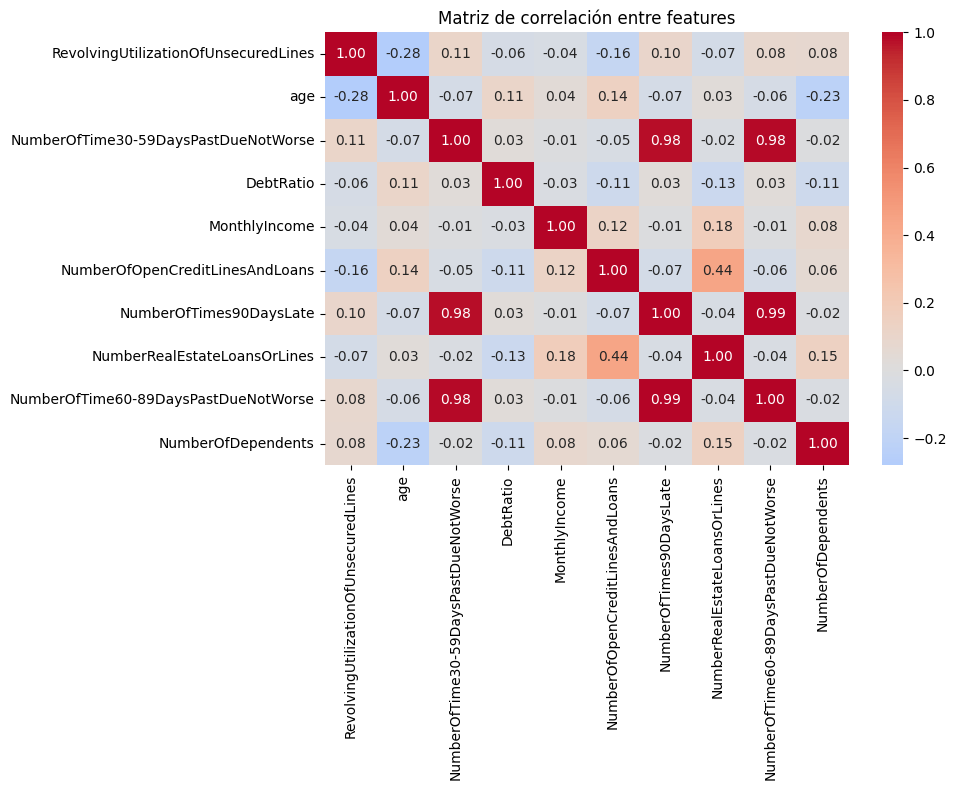

In [88]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_set.drop(columns=[target]).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre features")
plt.tight_layout()
plt.show()

In [89]:
corr_target = train_set.corr()[target].drop(target).sort_values(key=abs, ascending=False)
print("Correlación de cada feature con el target:")
print(corr_target)

Correlación de cada feature con el target:
RevolvingUtilizationOfUnsecuredLines    0.280751
age                                    -0.115529
NumberOfTime30-59DaysPastDueNotWorse    0.089787
NumberOfTimes90DaysLate                 0.088104
NumberOfTime60-89DaysPastDueNotWorse    0.064196
NumberOfDependents                      0.050414
NumberOfOpenCreditLinesAndLoans        -0.031254
MonthlyIncome                          -0.027884
DebtRatio                              -0.020486
NumberRealEstateLoansOrLines           -0.001130
Name: SeriousDlqin2yrs, dtype: float64


**Hallazgos:**
- `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse` y `NumberOfTimes90DaysLate` están **casi perfectamente correlacionadas entre sí** (r > 0.98): son redundantes y, en modelos basados en distancia (KNN, SVM), triplican el peso de la misma señal.
- `NumberRealEstateLoansOrLines` tiene una correlación prácticamente nula con el target (r ≈ 0.006): apenas aporta poder predictivo.

**Decisión:**
- Combinamos las tres variables de retraso en una sola (`TotalVecesRetraso`, suma de las tres) para quitar la redundancia sin perder la señal.
- Eliminamos `NumberRealEstateLoansOrLines` por su nula relación con el target.

In [90]:
delincuencia_cols = ["NumberOfTime30-59DaysPastDueNotWorse",
                      "NumberOfTime60-89DaysPastDueNotWorse",
                      "NumberOfTimes90DaysLate"]

# Combinamos las 3 variables de retraso (redundantes) en una sola, y quitamos la que no aporta señal
for X in (X_train, X_test):
    X["TotalVecesRetraso"] = X[delincuencia_cols].sum(axis=1)
    X.drop(columns=delincuencia_cols + ["NumberRealEstateLoansOrLines"], inplace=True)

print("Columnas finales:", list(X_train.columns))

Columnas finales: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents', 'TotalVecesRetraso']


#### Revisión de distribuciones y transformación log1p

Antes de escalar, revisamos la forma de cada variable (salvo `age`, que ya es razonablemente simétrica).

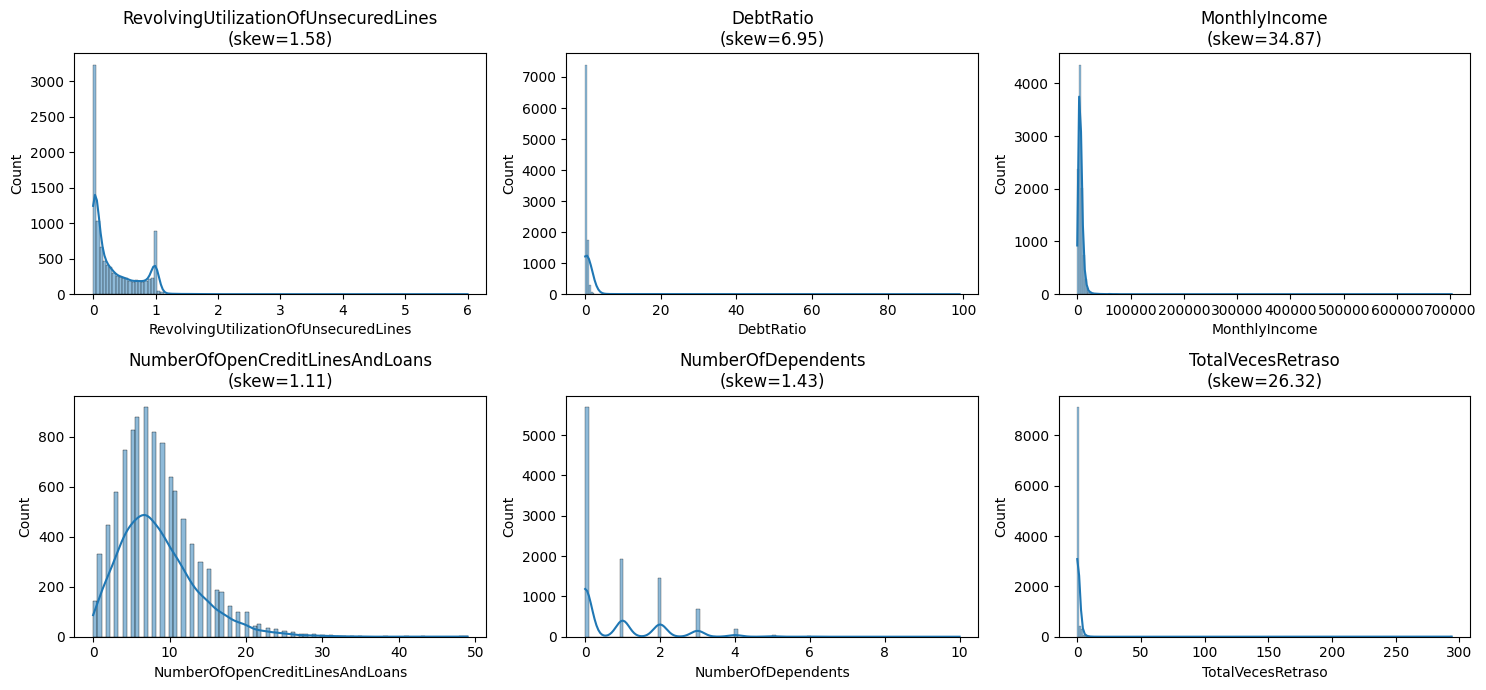

In [91]:
cols_a_revisar = [c for c in X_train.columns if c != "age"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), cols_a_revisar):
    sns.histplot(X_train[col], kde=True, ax=ax)
    ax.set_title(f"{col}\n(skew={X_train[col].skew():.2f})")
plt.tight_layout()
plt.show()

Todas presentan **asimetría positiva fuerte** (colas largas a la derecha, típico de variables monetarias y de conteo con algunos valores extremos). Aplicamos `log1p` (es decir, `log(1+x)`, válido porque no hay negativos) a todas las variables **excepto `age`**, para comprimir esas colas y que las distancias de KNN/SVM no estén dominadas por unos pocos valores extremos.

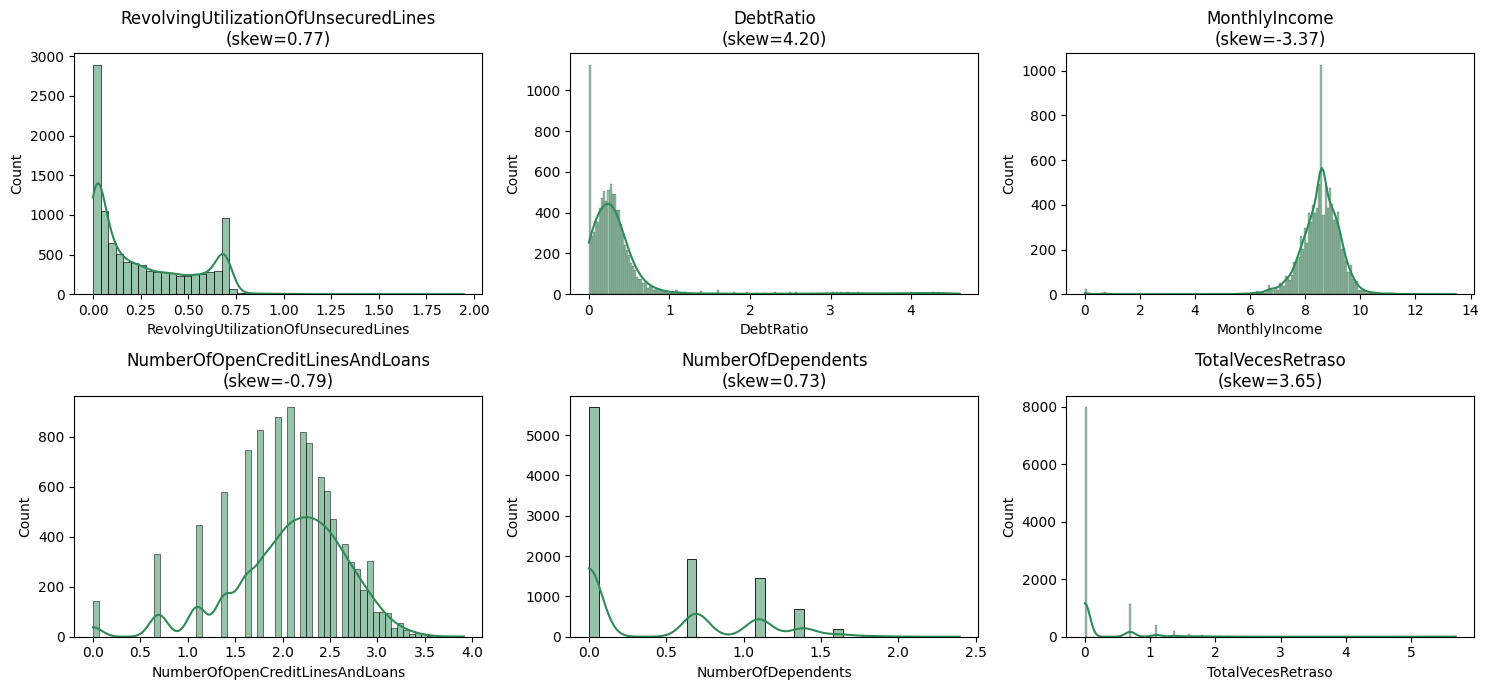

In [92]:
for X in (X_train, X_test):
    for col in cols_a_revisar:
        X[col] = np.log1p(X[col])

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), cols_a_revisar):
    sns.histplot(X_train[col], kde=True, ax=ax, color="seagreen")
    ax.set_title(f"{col}\n(skew={X_train[col].skew():.2f})")
plt.tight_layout()
plt.show()

La asimetría se reduce notablemente en la mayoría de variables tras el `log1p`. Ahora sí escalamos.

In [93]:
# Escalado estándar: obligatorio para KNN y SVM, que son sensibles a la escala de las variables
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

Train: (10029, 7)  |  Test: (2508, 7)


In [77]:
modelos = {
    "Regresión Logística": (LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42), X_train_sc),
    "KNN (k=5)":           (KNeighborsClassifier(n_neighbors=5),X_train_sc),
    "SVM lineal":          (LinearSVC(max_iter=10000, dual=False, random_state=42), X_train),
    "Random Forest":       (RandomForestClassifier(max_depth=5, class_weight="balanced", random_state=42),X_train),
    "XGBoost":              (XGBClassifier(random_state=42), X_train),
}

print("Comparación de modelos (CV=5) con SMOTE dentro del pipeline (sin fuga de datos)")
print("Métrica: recall (clase positiva = 'con dificultades')\n")
print(f"{'Modelo':<25} {'Media':>8} {'±Std':>7}")
print("-" * 43)

scores_dict = {}
for nombre, (modelo, X_datos) in modelos.items():

    scores = cross_val_score(modelo,X_datos, y_train,
        cv=5, scoring="recall", n_jobs=-1
    )
    scores_dict[nombre] = scores
    print(f"{nombre:<25} {scores.mean():>8.4f} {scores.std():>7.4f}")

mejor_nombre = max(scores_dict, key=lambda k: scores_dict[k].mean())
print(f"\nMejor modelo en CV: {mejor_nombre} "
      f"(recall = {scores_dict[mejor_nombre].mean():.4f})")

Comparación de modelos (CV=5) con SMOTE dentro del pipeline (sin fuga de datos)
Métrica: recall (clase positiva = 'con dificultades')

Modelo                       Media    ±Std
-------------------------------------------
Regresión Logística         0.7525  0.0416
KNN (k=5)                   0.1664  0.0147
SVM lineal                  0.0246  0.0073
Random Forest               0.7264  0.0516
XGBoost                     0.1925  0.0249

Mejor modelo en CV: Regresión Logística (recall = 0.7525)


#### Balanceo con SMOTE

Dado el fuerte desequilibrio (~7% clase positiva), usamos **SMOTE** (*Synthetic Minority Over-sampling Technique*) para equilibrar las clases. SMOTE genera muestras sintéticas de la clase minoritaria interpolando entre vecinos existentes. La siguiente celda es solo una **demostración** de su efecto sobre el balance de clases; **no usaremos este `X_train_bal` directamente para validar modelos** (ver la nota importante más abajo).

In [78]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print("Distribución y_train original:")
print(y_train.value_counts(normalize=True).map(lambda x: f"{x:.1%}"))
print(f"\nDistribución y_train tras SMOTE:")
print(pd.Series(y_train_bal).value_counts(normalize=True).map(lambda x: f"{x:.1%}"))
print(f"\nMuestras en train balanceado: {len(y_train_bal):,}")

Distribución y_train original:
SeriousDlqin2yrs
0    93.1%
1     6.9%
Name: proportion, dtype: str

Distribución y_train tras SMOTE:
SeriousDlqin2yrs
0    50.0%
1    50.0%
Name: proportion, dtype: str

Muestras en train balanceado: 18,676


#### Ajuste de Hiperparámetros del Mejor Modelo

Tomamos el modelo que ha ganado la comparación anterior (`mejor_nombre`) y ajustamos sus hiperparámetros con GridSearchCV, aplicando de nuevo SMOTE **dentro** del pipeline para evitar la fuga de datos, usando **recall** como criterio de selección.

In [79]:
param_grids = {
    "Regresión Logística": {"modelo__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    "KNN (k=5)": {
        "modelo__n_neighbors": [3, 5, 7, 9, 11, 15, 21],   # K: nº de vecinos consultados (pocos = límites inestables, muchos = más suavizado)
        "modelo__weights":     ["uniform", "distance"],     # uniform: todos los vecinos pesan igual | distance: pesan más los más cercanos
        "modelo__metric":      ["euclidean", "manhattan"],  # forma de medir la distancia entre puntos
    },
    "SVM lineal": {"modelo__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    "Random Forest": {
        "modelo__n_estimators":     [100, 200],
        "modelo__max_depth":        [5, 10, None],
        "modelo__min_samples_leaf": [1, 5],
    },
    "XGBoost": {
        "modelo__n_estimators":  [100, 200],
        "modelo__max_depth":     [3, 5, 7],
        "modelo__learning_rate": [0.01, 0.1],
    },
}

modelo_base, X_datos_mejor = modelos[mejor_nombre]
pipe_mejor = ImbPipeline([("smote", SMOTE(random_state=42)), ("modelo", modelo_base)])

gs_mejor = GridSearchCV(
    pipe_mejor,
    param_grids[mejor_nombre],
    cv=5,
    scoring="recall",
    n_jobs=-1
)
gs_mejor.fit(X_datos_mejor, y_train)

print(f"Mejor modelo: {mejor_nombre}")
print("Mejores hiperparámetros:", gs_mejor.best_params_)
print(f"Mejor recall (CV):  {gs_mejor.best_score_:.4f}")

Mejor modelo: Regresión Logística
Mejores hiperparámetros: {'modelo__C': 1}
Mejor recall (CV):  0.7525


#### Evaluación sobre Test

Evaluamos el mejor modelo (`mejor_nombre`, con sus hiperparámetros optimizados) sobre el conjunto de test, usando el mismo tipo de datos (escalados o sin escalar) con el que se entrenó.

In [80]:
mejor_modelo_final = gs_mejor.best_estimator_
y_pred_test = mejor_modelo_final.predict(X_test if X_datos_mejor is X_train else X_test_sc)

print(f"=== Evaluación de {mejor_nombre} optimizado sobre Test ===\n")
print(classification_report(
    y_test, y_pred_test,
    target_names=["Sin dificultades (0)", "Con dificultades (1)"],
    digits=4
))
print(f"Recall (clase 1):    {recall_score(y_test, y_pred_test):.4f}")
print(f"Balanced accuracy:   {balanced_accuracy_score(y_test, y_pred_test):.4f}")

=== Evaluación de Regresión Logística optimizado sobre Test ===

                      precision    recall  f1-score   support

Sin dificultades (0)     0.9743    0.7957    0.8760      2335
Con dificultades (1)     0.2063    0.7168    0.3204       173

            accuracy                         0.7903      2508
           macro avg     0.5903    0.7562    0.5982      2508
        weighted avg     0.9213    0.7903    0.8377      2508

Recall (clase 1):    0.7168
Balanced accuracy:   0.7562


#### Análisis de Errores

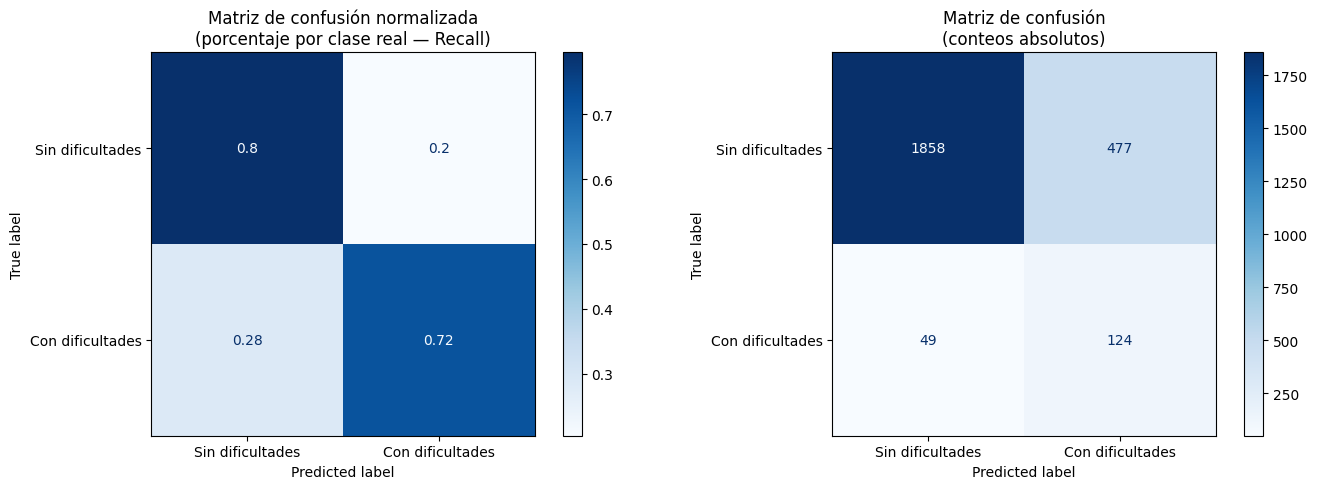

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["Sin dificultades", "Con dificultades"],
    normalize="true",
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Matriz de confusión normalizada\n(porcentaje por clase real — Recall)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["Sin dificultades", "Con dificultades"],
    ax=axes[1],
    cmap="Blues"
)
axes[1].set_title("Matriz de confusión\n(conteos absolutos)")

plt.tight_layout()
plt.show()

**Análisis de los errores:**

Tras corregir la fuga de datos y ampliar la comparación a 5 modelos optimizando **recall**, el modelo ganador en la comparación honesta es **Regresión Logística** (empatada técnicamente con SVM lineal, ~0.75 de recall en CV; nos quedamos con Regresión Logística por ser igual de buena y más simple/interpretable, además de ofrecer `predict_proba` para ajustar el umbral si se quisiera). Sorprende que KNN, Random Forest y XGBoost queden por debajo: con los hiperparámetros por defecto y el desequilibrio de clases, estos modelos son más conservadores a la hora de predecir la clase minoritaria, mientras que un modelo lineal regularizado generaliza mejor ese patrón con pocos datos de la clase positiva.

La matriz de confusión normalizada por filas muestra el **recall** de cada clase real:

- **Clase 0 (sin dificultades)**: el modelo acierta en la mayoría de los casos, con un número moderado de falsos positivos (clientes sin riesgo que se marcan como en riesgo).
- **Clase 1 (con dificultades)**: el recall es alto (en torno al 70-75%), justo el objetivo que pedía negocio. A cambio, la precisión de esta clase es baja: bastantes avisos de riesgo son falsos positivos. Los **falsos negativos** (personas en riesgo real que el modelo no detecta) siguen siendo el error más crítico para el negocio, ya que suponen conceder crédito a clientes que entrarán en mora — y es justamente lo que minimizamos al optimizar recall.

**Posibles mejoras:**
1. Ajustar el **umbral de decisión** (con `predict_proba`) para encontrar el punto óptimo de compromiso precisión/recall en la clase 1, según el coste de negocio de un FN vs. un FP.
2. Probar más combinaciones de balanceo (SMOTE + `RandomUnderSampler`) y de hiperparámetros para Random Forest/XGBoost, que podrían mejorar con un tuning más fino (p. ej. `scale_pos_weight` en XGBoost).
3. Ensamblar varios modelos (votación o stacking) para combinar sus fortalezas.
4. Seguir afinando la ingeniería de características (ratios entre deuda e ingresos, interacciones entre variables).